In [2]:
# Step 1: Imports and functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from scipy.interpolate import griddata
from matplotlib.ticker import FormatStrFormatter
import alphashape
from shapely.geometry import Polygon, MultiPolygon

In [3]:
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'

In [4]:

def hammer_projection(phi, theta, phi_center=np.pi, theta_center=np.pi/2):
    """
    Convert spherical coordinates to Hammer projection coordinates
    """
    phi_centered = phi - phi_center
    theta_shifted = theta - theta_center + np.pi/2
    lat = np.pi/2 - theta_shifted
    
    denominator = np.sqrt(1 + np.cos(lat) * np.cos(phi_centered/2))
    
    x = 2 * np.sqrt(2) * np.cos(lat) * np.sin(phi_centered/2) / denominator
    y = np.sqrt(2) * np.sin(lat) / denominator
    
    return x, y


def create_segment_boundary(phi_lim, theta_lim, phi_center, theta_center, n_points=200):
    """
    Create the curved boundary of a spherical segment in Hammer projection
    """
    phi_min, phi_max = phi_lim
    theta_min, theta_max = theta_lim
    
    boundary_points = []
    
    # Bottom edge (theta = theta_min)
    phi_bottom = np.linspace(phi_min, phi_max, n_points//4)
    theta_bottom = np.full_like(phi_bottom, theta_min)
    x_bottom, y_bottom = hammer_projection(phi_bottom, theta_bottom, phi_center, theta_center)
    boundary_points.extend(list(zip(x_bottom, y_bottom)))
    
    # Right edge (phi = phi_max)
    theta_right = np.linspace(theta_min, theta_max, n_points//4)
    phi_right = np.full_like(theta_right, phi_max)
    x_right, y_right = hammer_projection(phi_right, theta_right, phi_center, theta_center)
    boundary_points.extend(list(zip(x_right, y_right)))
    
    # Top edge (theta = theta_max)
    phi_top = np.linspace(phi_max, phi_min, n_points//4)
    theta_top = np.full_like(phi_top, theta_max)
    x_top, y_top = hammer_projection(phi_top, theta_top, phi_center, theta_center)
    boundary_points.extend(list(zip(x_top, y_top)))
    
    # Left edge (phi = phi_min)
    theta_left = np.linspace(theta_max, theta_min, n_points//4)
    phi_left = np.full_like(theta_left, phi_min)
    x_left, y_left = hammer_projection(phi_left, theta_left, phi_center, theta_center)
    boundary_points.extend(list(zip(x_left, y_left)))
    
    return np.array(boundary_points)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.ticker import FormatStrFormatter
from scipy.interpolate import griddata

# -----------------------------------------------------------------------------
# Utilities required (must be supplied elsewhere in the notebook / package):
# * hammer_projection(phi, theta, phi_c, theta_c)  – forward Hammer axis projection
# * create_segment_boundary(phi_lim, theta_lim, phi_c, theta_c) – helper that
#   returns an (N,2) array of projected boundary points for a rectangular
#   (phi, theta) window.  Both functions are unchanged from your original code.
# -----------------------------------------------------------------------------

def plot_contour_curved(
    df,
    value_col: str,
    *,
    title: str = "Curvature map",
    theta_lim: tuple[float, float] | None = None,
    phi_lim: tuple[float, float] | None = None,
    n_levels: int = 21,
    cmap: str = "RdBu_r",
    figsize=(10, 8),
    n_tick: int = 5,
    show_tick_labels: bool = True
):
    """Plot *value_col* from *df* on a customised Hammer projection.

    Parameters
    ----------
    df : pandas.DataFrame
        Columns required: ``theta`` (rad), ``phi`` (rad) and *value_col*.
    value_col : str
        Column to visualise.
        * ``'density'`` – points are binary (all 1); grid interpolation is
          skipped and only a **black outline** of the occupied region is drawn.
        * anything else – values are interpolated to a regular grid and shown
          with a filled contour map.
    theta_lim, phi_lim : tuple(float, float) | None
        If supplied, restrict viewing window in radians.
    n_levels : int
        Number of colour levels for filled‑contour maps (ignored for density).
    cmap : str
        Matplotlib colour map for non‑density plots.
    figsize : tuple
        Figure size in inches.
    n_tick : int
        Number of tick‑marks along each boundary edge when limits are set.
    """

    # ------------------------------------------------------------------
    # 1.  Extract data & basic scaling ----------------------------------
    # ------------------------------------------------------------------
    th = df["theta"].to_numpy()
    ph = df["phi"].to_numpy()

    if value_col == "gaussian":
        val = df[value_col].to_numpy() * 1e6
        cbar_label = r"Gaussian curvature ($\times 10^{-6}\,\mathrm{\AA}^{2}$)"
    elif value_col == "extrinsic":
        val = df[value_col].to_numpy() * 1e3
        cbar_label = r"Mean curvature ($\times 10^{-3}\,\mathrm{\AA}^{-1}$)"
    else:
        val = df[value_col].to_numpy()
        cbar_label = value_col

    # Mask NaNs ----------------------------------------------------------
    m = ~np.isnan(th) & ~np.isnan(ph) & ~np.isnan(val)
    th, ph, val = th[m], ph[m], val[m]

    # Apply angular limits ----------------------------------------------
    if theta_lim is not None:
        m = (th >= theta_lim[0]) & (th <= theta_lim[1])
        th, ph, val = th[m], ph[m], val[m]
    if phi_lim is not None:
        m = (ph >= phi_lim[0]) & (ph <= phi_lim[1])
        th, ph, val = th[m], ph[m], val[m]
    if val.size == 0:
        raise ValueError("No data in specified range!")

    # ------------------------------------------------------------------
    # 2.  Projection to Hammer coordinates ------------------------------
    # ------------------------------------------------------------------
    phi_c = (phi_lim[0] + phi_lim[1]) / 2 if phi_lim else np.pi
    theta_c = (theta_lim[0] + theta_lim[1]) / 2 if theta_lim else np.pi / 2

    x_d, y_d = hammer_projection(ph, th, phi_c, theta_c)

    # Boundary path for clipping / drawing ------------------------------
    boundary_path: Path | None = None
    boundary_pts = None
    if phi_lim and theta_lim:
        boundary_pts = create_segment_boundary(phi_lim, theta_lim, phi_c, theta_c)
        boundary_path = Path(boundary_pts)

    # ------------------------------------------------------------------
    # 3.  Figure & axis --------------------------------------------------
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize, facecolor="none")
    
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["font.size"] = 20

    # Axis background
    ax.set_facecolor("none")                                   # axes patch transparent
    ax.patch.set_alpha(0) 

    # ------------------------------------------------------------------
    # Branch A – density  → user‑chosen α‑shape outline
    # ------------------------------------------------------------------
    if value_col == "density":
        import alphashape
        from shapely.geometry import Polygon, MultiPolygon

        # <<< tweak until the outline is as tight as you like >>>
        alpha = 30            # smaller → tighter; larger → smoother
        # --------------------------------------------------------------

        alpha_geom = alphashape.alphashape(
            list(zip(x_d, y_d)), alpha=alpha
        )

        # Handle Polygon vs MultiPolygon
        polys = (
            [alpha_geom] if isinstance(alpha_geom, Polygon)
            else list(alpha_geom.geoms) if isinstance(alpha_geom, MultiPolygon)
            else []
        )
        if not polys:
            raise ValueError(
                "alphashape returned an empty geometry – try a larger α"
            )

        # Draw outline(s)
        for poly in polys:
            xs, ys = poly.exterior.xy
            ax.plot(xs, ys, color="k", lw=1.2)

        # 4.4  Axis limits & curved boundary  ---------------------------
        if boundary_path is not None:
            # draw the ASU border and keep the same limits you used before
            ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], color="black", lw=1.5)
            ax.set_xlim(boundary_pts[:, 0].min() - 0.05,
                        boundary_pts[:, 0].max() + 0.05)
            ax.set_ylim(boundary_pts[:, 1].min() - 0.05,
                        boundary_pts[:, 1].max() + 0.05)
        else:
            # fallback: pad the hull’s box
            pad = 0.05
            all_x = np.concatenate([poly.exterior.xy[0] for poly in polys])
            all_y = np.concatenate([poly.exterior.xy[1] for poly in polys])
            ax.set_xlim(all_x.min() - pad, all_x.max() + pad)
            ax.set_ylim(all_y.min() - pad, all_y.max() + pad)

        # keep projection proportions square
        # ax.set_aspect("equal", adjustable="box")
        # *No* ax.set_aspect(...)  → avoids vertical squeezing
        cbar = None

    # ------------------------------------------------------------------
    # 5.  Branch B – other value columns → filled‑contour map -----------
    # ------------------------------------------------------------------
    else:
        # Padding for grid extents
        pad = 0.15
        x_min, x_max = x_d.min(), x_d.max()
        y_min, y_max = y_d.min(), y_d.max()
        x_rng, y_rng = x_max - x_min, y_max - y_min
        x_min -= pad * x_rng
        x_max += pad * x_rng
        y_min -= pad * y_rng
        y_max += pad * y_rng

        # Regular grid
        nx = ny = 180
        X, Y = np.meshgrid(
            np.linspace(x_min, x_max, nx), np.linspace(y_min, y_max, ny)
        )
        Z = griddata(np.column_stack((x_d, y_d)), val, (X, Y), method="linear")

        # Clip outside boundary
        if boundary_path is not None:
            inside = boundary_path.contains_points(np.column_stack((X.ravel(), Y.ravel())))
            Z = np.where(inside.reshape(X.shape), Z, np.nan)
        # ------------------------------------------------------------------
        # 3.4  Colour levels & palette
        # ------------------------------------------------------------------
        if value_col == "spacing":
        # sequential palette, no centring at 0
            cmap_used = "YlOrBr"      # choose any matplotlib single‑hue map
            vmin, vmax = np.nanmin(val), np.nanmax(val)
            levels = np.linspace(vmin, vmax, n_levels)
        elif value_col == "gaussian":
        # original: diverging palette centred on 0
            vmax = np.nanmax(np.abs(val))
            levels = np.linspace(-vmax+15, vmax-15, n_levels)
            print(vmax)
        else:
        # original: diverging palette centred on 0
            cmap_used = cmap
            vmax = np.nanmax(np.abs(val))
            levels = np.linspace(-vmax, vmax, n_levels)

            # Symmetric colour levels about zero
            vmax = np.nanmax(np.abs(val))
            levels = np.linspace(-vmax, vmax, n_levels)

        cs = ax.contourf(
            X,Y,Z,
            levels=levels,
            cmap=cmap_used,
            extend="both",
            antialiased=True,
        )
        ax.contour(
            X,Y,Z,
            levels=levels[::2],
            colors="k",
            linewidths=0.3,
            alpha=0.15,
        )

        # Boundary & axis limits
        if boundary_path is not None:
            ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], color="black", lw=1.5)
            ax.set_xlim(boundary_pts[:, 0].min() - 0.05, boundary_pts[:, 0].max() + 0.05)
            ax.set_ylim(boundary_pts[:, 1].min() - 0.05, boundary_pts[:, 1].max() + 0.05)
        else:
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)

        # Colour‑bar
        cbar = fig.colorbar(cs, ax=ax,orientation="vertical",pad=0.02,  shrink=0.8)    # tweak spacing/size to taste

    # ------------------------------------------------------------------
    # 6.  Meridian / parallel grid (subtle background reference) --------
    # ------------------------------------------------------------------
    def _proj_phi(phi_val):
        th_line = np.linspace(theta_lim[0] if theta_lim else 0,
                               theta_lim[1] if theta_lim else np.pi, 100)
        return hammer_projection(np.full_like(th_line, phi_val), th_line, phi_c, theta_c)

    def _proj_theta(theta_val):
        ph_line = np.linspace(phi_lim[0] if phi_lim else 0,
                               phi_lim[1] if phi_lim else 2 * np.pi, 100)
        return hammer_projection(ph_line, np.full_like(ph_line, theta_val), phi_c, theta_c)

    phi_vals = (
        np.linspace(phi_lim[0], phi_lim[1], n_tick)
        if phi_lim else np.linspace(0, 2 * np.pi, 9)
    )
    theta_vals = (
        np.linspace(theta_lim[0], theta_lim[1], n_tick)
        if theta_lim else np.linspace(0, np.pi, 6)
    )

    for phi_v in phi_vals:
        x_l, y_l = _proj_phi(phi_v)
        ax.plot(x_l, y_l, color="#000", lw=0.5, alpha=0.3)

    for th_v in theta_vals:
        x_l, y_l = _proj_theta(th_v)
        ax.plot(x_l, y_l, color="#000", lw=0.5, alpha=0.3)
        
    # ------------------------------------------------------------------
    # 7.  Boundary tick‑marks & labels (π‑based numbering)
    # ------------------------------------------------------------------
    if phi_lim and theta_lim and boundary_path is not None:
        phi_ticks   = np.linspace(phi_lim[0],   phi_lim[1],   n_tick)
        theta_ticks = np.linspace(theta_lim[0], theta_lim[1], n_tick)

        # Tick length ≈ 2 % of the span in the outward direction
        d_th = 0.02 * (theta_lim[1] - theta_lim[0])
        d_ph = 0.02 * (phi_lim[1] - phi_lim[0])

        def _add_tick(x0, y0, x1, y1, txt, ha, va):
            """Draw a tick-mark and, optionally, its label."""
            ax.plot([x0, x1], [y0, y1], color="k", lw=1.0)
            if show_tick_labels:
                dx, dy = x1 - x0, y1 - y0
                ax.text(x1 + 0.6 * dx, y1 + 0.6 * dy, txt, ha=ha, va=va, fontsize=12)

        # -- φ ticks: along the *top* edge (θ = θ_min)
        for phi_t in phi_ticks:
            x0, y0 = hammer_projection(phi_t, theta_lim[0],       phi_c, theta_c)
            x1, y1 = hammer_projection(phi_t, theta_lim[0] - d_th, phi_c, theta_c)
            _add_tick(x0, y0, x1, y1, f"{np.degrees(phi_t):.0f}°", ha="center", va="top")

        # -- θ ticks: left & right vertical edges
        for th_t in theta_ticks:
            # left edge (φ = φ_min)
            x0, y0 = hammer_projection(phi_lim[0], th_t,       phi_c, theta_c)
            x1, y1 = hammer_projection(phi_lim[0] - d_ph, th_t, phi_c, theta_c)
            _add_tick(x0, y0, x1, y1, f"{np.degrees(th_t):.0f}°", ha="right", va="center")
            # right edge (φ = φ_max)
            x0r, y0r = hammer_projection(phi_lim[1], th_t,       phi_c, theta_c)
            x1r, y1r = hammer_projection(phi_lim[1] + d_ph, th_t, phi_c, theta_c)
            _add_tick(x0r, y0r, x1r, y1r, f"{np.degrees(th_t):.0f}°", ha="left",  va="center")

    # ------------------------------------------------------------------
    # 8.  Colour‑bar label & final cosmetics
    # ------------------------------------------------------------------
    if cbar is not None:
        cbar.set_label(cbar_label, fontsize=9)
        cbar.ax.tick_params(labelsize=7)
        cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        cbar.ax.set_facecolor("none")      # colour‑bar axes transparent
        cbar.ax.patch.set_alpha(0)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=11, pad=8)
    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.tight_layout()
    return fig, ax

In [6]:

csv_path = 'outer_leaflet_df3.csv'  
outer_df = pd.read_csv(csv_path)

# Preview the data
print(outer_df.head())

       x_coor     y_coor      z_coor      rho     theta       phi  gaussian  \
0  704.361396  61.623637 -165.837536  726.240  0.087266  1.801180 -0.000013   
1  700.848008  61.316256 -167.603328  723.214  0.087266  1.804670 -0.000007   
2  703.190882  61.521230 -170.769608  726.240  0.087266  1.808161 -0.000004   
3  702.592769  61.468902 -173.232538  726.240  0.087266  1.811652 -0.000003   
4  699.061153  61.159926 -174.961302  723.214  0.087266  1.815142 -0.000003   

   extrinsic  spacing  direction  
0  -0.000533      NaN          1  
1   0.000168   24.208          2  
2   0.000673   27.234          3  
3   0.000641   30.260          4  
4   0.000802   24.208          5  


In [28]:
# sphe = 1 / rho^2

print(min(outer_df["rho"]))
print(max(outer_df["rho"]))

outer_df_sph = outer_df.assign(
    sphericity=(
        np.sign(outer_df["gaussian"]) == np.sign(outer_df["extrinsic"])
    ).astype(int)
)



print(outer_df_sph)
print(min(outer_df_sph["gaussian"]))


699.0059999999999
789.786
            x_coor     y_coor      z_coor      rho     theta       phi  \
0       704.361396  61.623637 -165.837536  726.240  0.087266  1.801180   
1       700.848008  61.316256 -167.603328  723.214  0.087266  1.804670   
2       703.190882  61.521230 -170.769608  726.240  0.087266  1.808161   
3       702.592769  61.468902 -173.232538  726.240  0.087266  1.811652   
4       699.061153  61.159926 -174.961302  723.214  0.087266  1.815142   
...            ...        ...         ...      ...       ...       ...   
238442  -78.394614  13.823086 -709.685447  714.136  2.967060  3.029892   
238443  -75.954507  13.392829 -709.958993  714.136  2.967060  3.033382   
238444  -73.824973  13.017335 -713.233312  717.162  2.967060  3.036873   
238445  -71.372697  12.584932 -713.490639  717.162  2.967060  3.040364   
238446  -68.919552  12.152377 -713.739273  717.162  2.967060  3.043854   

        gaussian  extrinsic  spacing  direction  sphericity  
0      -0.000013  -0.00

In [9]:
asu_path = 'asu_df.csv'
asu_df = pd.read_csv(asu_path)

In [10]:
pentasym_path = 'pentasym_df.csv'
pentasym_df = pd.read_csv(pentasym_path)

In [11]:
trisym_path = 'trisym_df.csv'
trisym_df = pd.read_csv(trisym_path)

In [12]:
penfu1_path = "penfu1_df.csv"
penfu1_df = pd.read_csv(penfu1_path)

In [13]:
penfu2_path = "penfu2_df.csv"
penfu2_df = pd.read_csv(penfu2_path)

(<Figure size 1000x800 with 1 Axes>, <Axes: title={'center': 'ASU'}>)

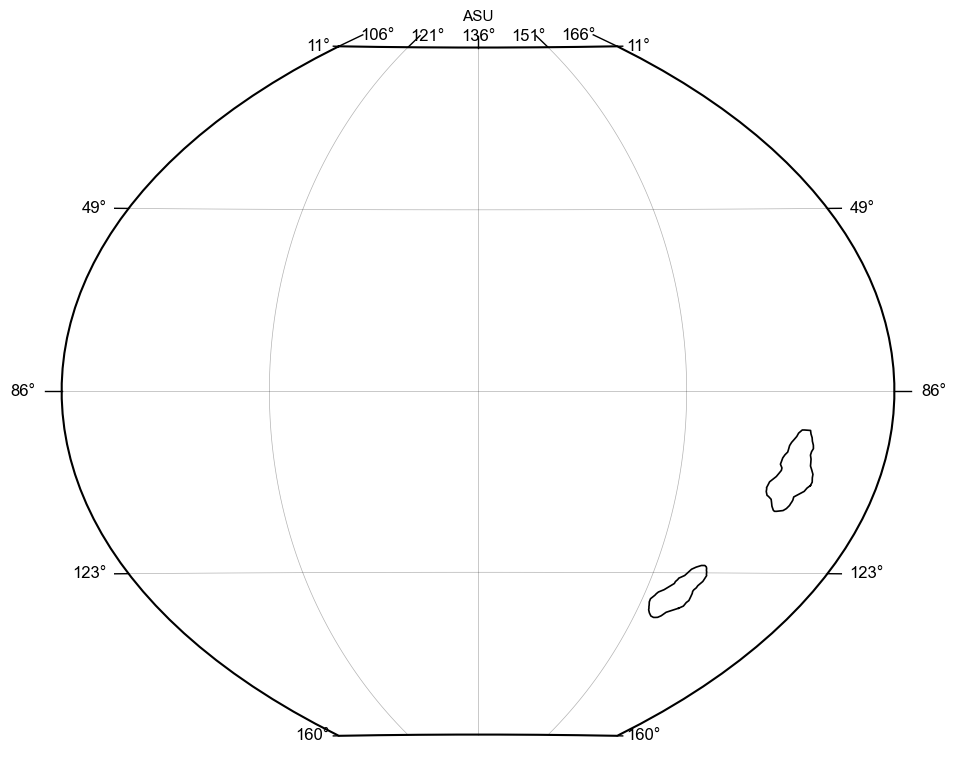

In [41]:
plot_contour_curved(penfu2_df,value_col='density', title='ASU',
                       theta_lim=(0.2, 2.8), phi_lim=(1.85, 2.9), n_levels=2)

(<Figure size 1000x800 with 1 Axes>, <Axes: title={'center': 'ASU'}>)

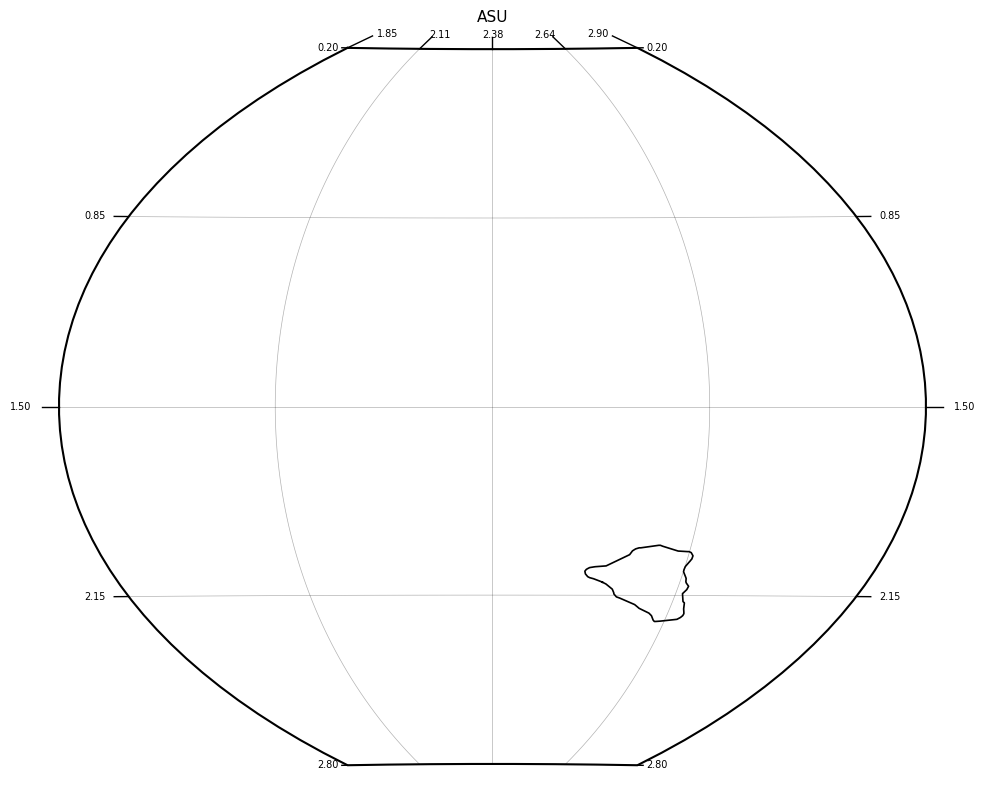

In [10]:
plot_contour_curved(penfu1_df,value_col='density', title='ASU',
                       theta_lim=(0.2, 2.8), phi_lim=(1.85, 2.9), n_levels=2)

(<Figure size 1000x800 with 1 Axes>, <Axes: title={'center': 'ASU'}>)

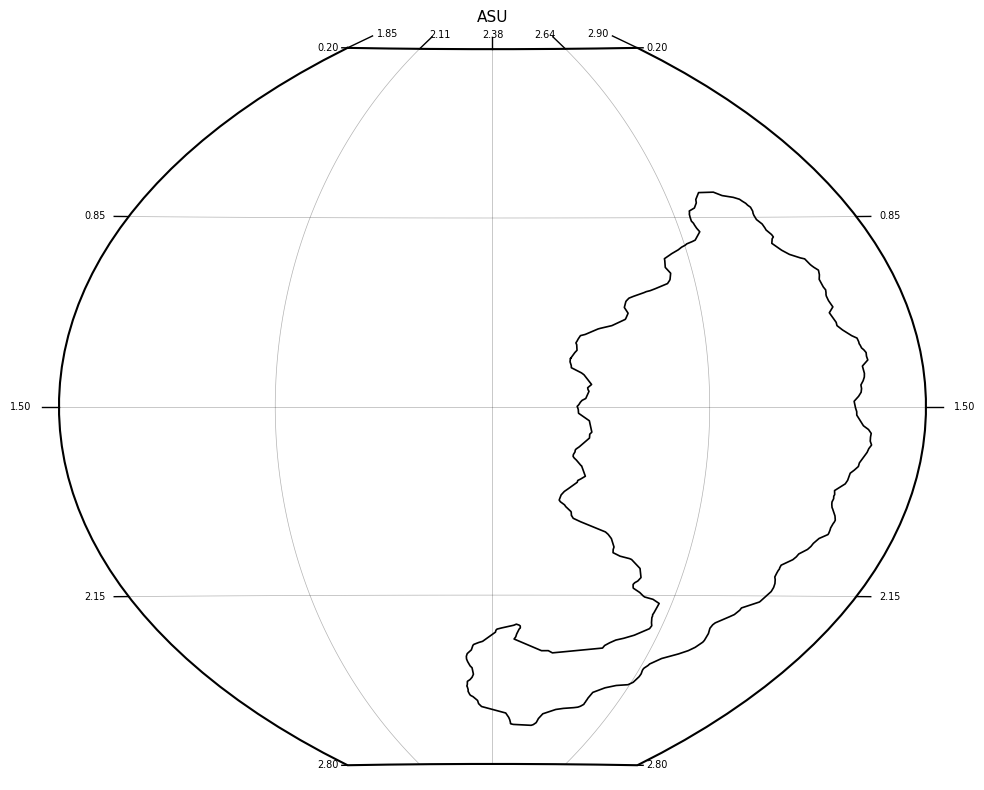

In [25]:
plot_contour_curved(asu_df,value_col='density', title='ASU',
                       theta_lim=(0.2, 2.8), phi_lim=(1.85, 2.9), n_levels=2)

(<Figure size 1000x800 with 1 Axes>, <Axes: title={'center': 'Pentasym'}>)

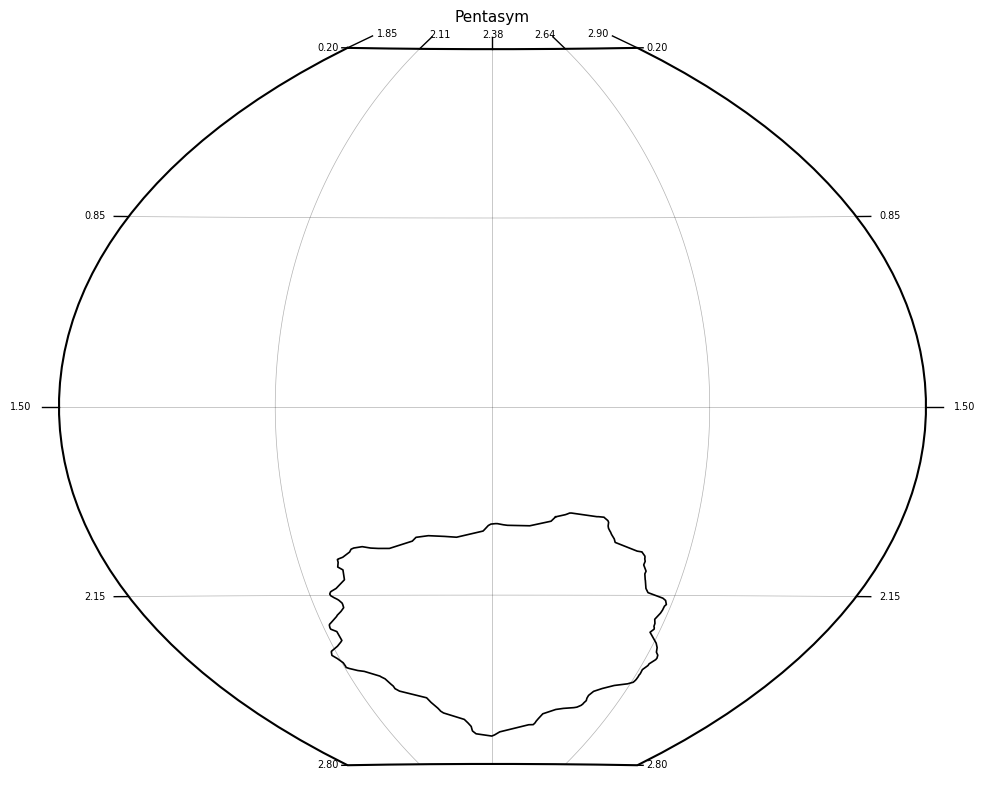

In [17]:
plot_contour_curved(pentasym_df,value_col='density', title='Pentasym',
                       theta_lim=(0.2, 2.8), phi_lim=(1.85, 2.9), n_levels=2)

(<Figure size 1000x800 with 1 Axes>, <Axes: title={'center': 'Trisym'}>)

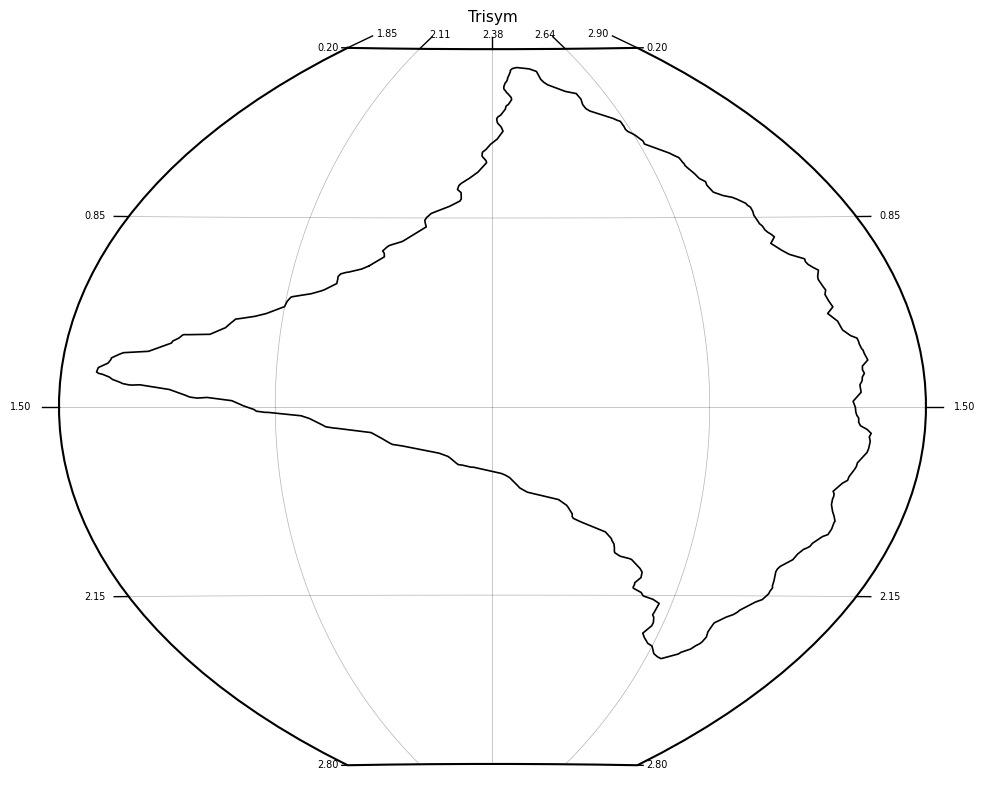

In [18]:
plot_contour_curved(trisym_df,value_col='density', title='Trisym',
                       theta_lim=(0.2, 2.8), phi_lim=(1.85, 2.9), n_levels=2)

50.0266820363726
Figure(1000x800)


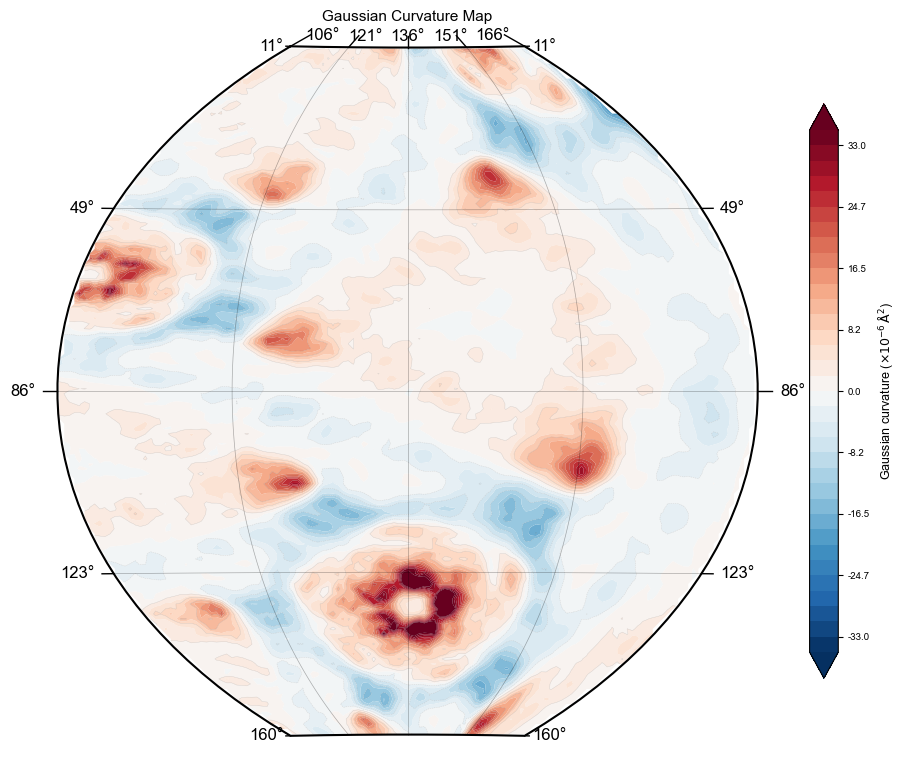

In [26]:
gaussian_fig, guassian_ax = plot_contour_curved(outer_df,value_col='gaussian', title='Gaussian Curvature Map',
                       theta_lim=(0.2, 2.8), phi_lim=(1.85, 2.9), n_levels=35)
print(gaussian_fig)

gaussian_fig.savefig("curvature_analysis/gaussian_plot2.svg", transparent=True)

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Gaussian Curvature Map'}>)

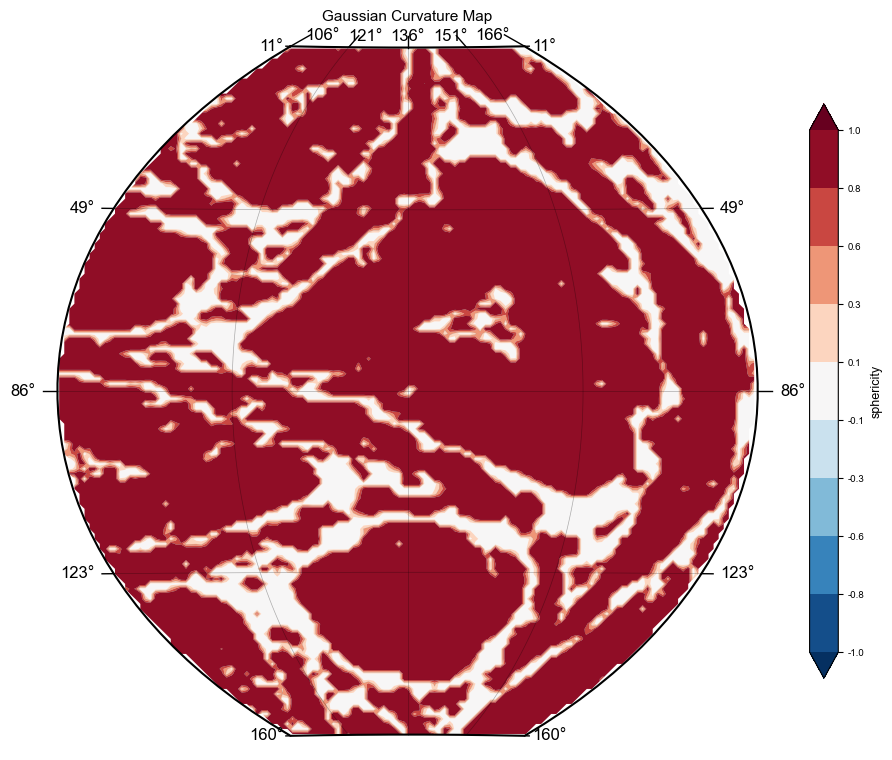

In [29]:
plot_contour_curved(outer_df_sph,value_col='sphericity', title='Gaussian Curvature Map',
                       theta_lim=(0.2, 2.8), phi_lim=(1.85, 2.9), n_levels = 10)

50.0266820363726


(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Gaussian Curvature Map'}>)

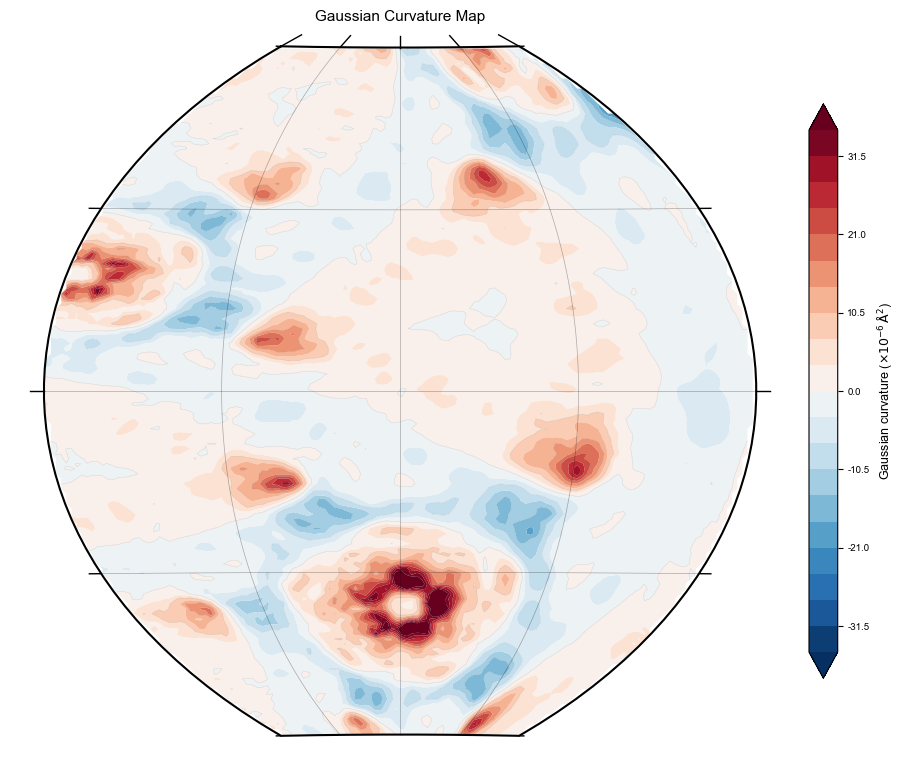

In [23]:
plot_contour_curved(outer_df,value_col='gaussian', title='Gaussian Curvature Map',
                       theta_lim=(0.2, 2.8), phi_lim=(1.85, 2.9), n_levels=21,  show_tick_labels = False)

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Mean Curvature Map'}>)

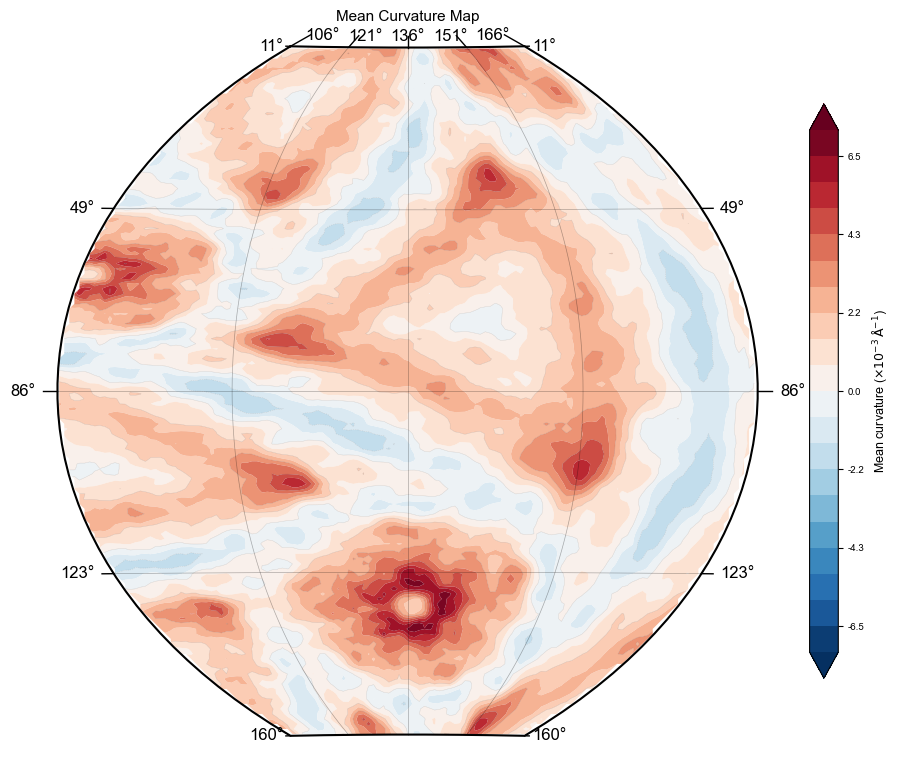

In [30]:
plot_contour_curved(outer_df,value_col='extrinsic', title='Mean Curvature Map',
                       theta_lim=(0.2, 2.8), phi_lim=(1.85, 2.9), n_levels=21)

Figure(1000x800)


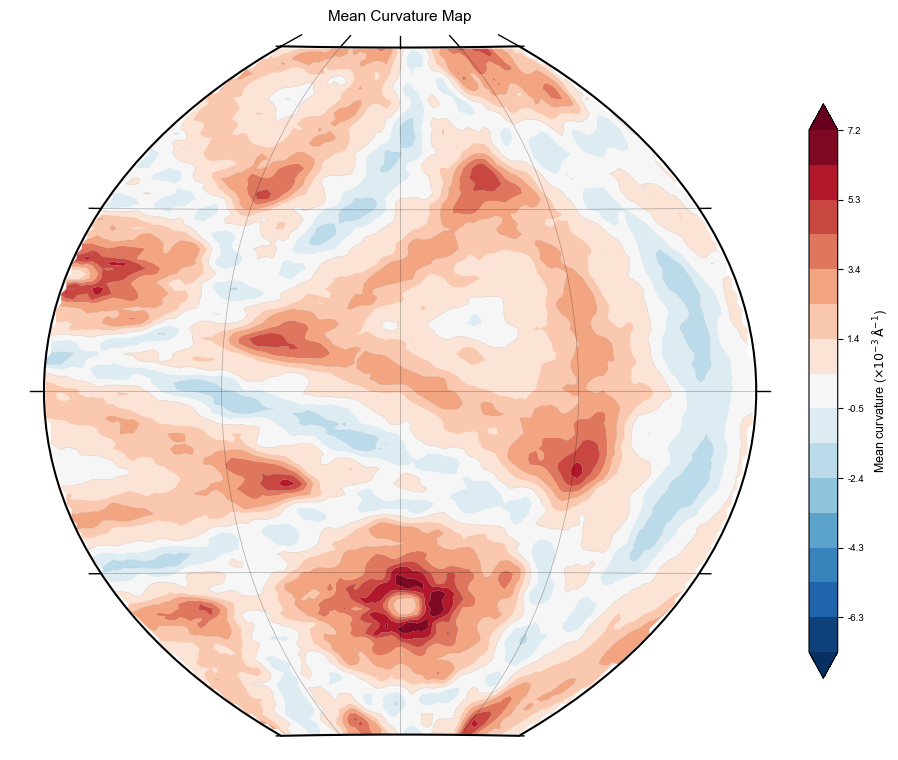

In [64]:
mean_fig, mean_ax = plot_contour_curved(outer_df,value_col='extrinsic', title='Mean Curvature Map',
                       theta_lim=(0.2, 2.8), phi_lim=(1.85, 2.9), n_levels=16, show_tick_labels = False)
print(mean_fig)

mean_fig.savefig("curvature_analysis/mean_plot.svg", transparent=True)

Figure(1000x800)


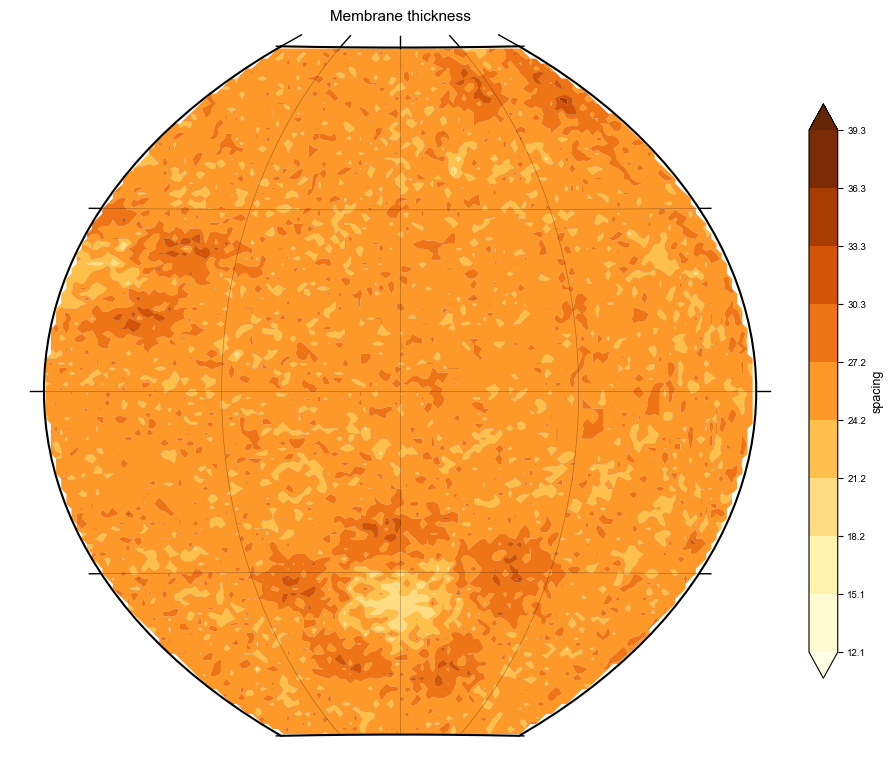

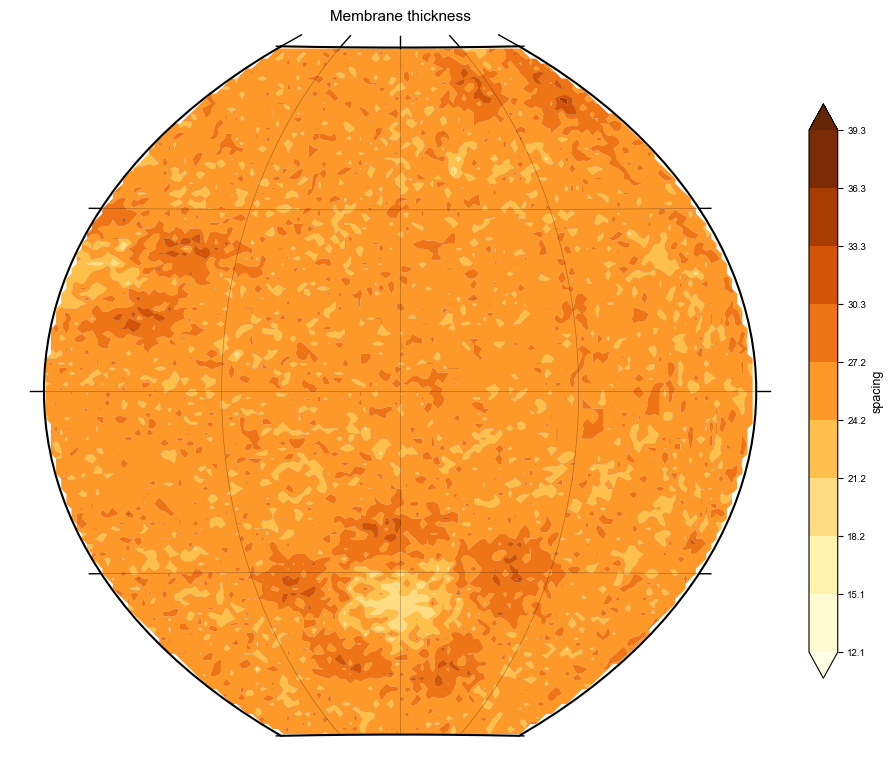

In [65]:
plot_contour_curved(outer_df,value_col='spacing', title='Membrane thickness',
                       theta_lim=(0.2, 2.8), phi_lim=(1.85, 2.9), n_levels=10, show_tick_labels = False)

spacing_fig, spacing_ax = plot_contour_curved(outer_df,value_col='spacing', title='Membrane thickness',
                       theta_lim=(0.2, 2.8), phi_lim=(1.85, 2.9), n_levels=10, show_tick_labels = False)
print(spacing_fig)

spacing_fig.savefig("curvature_analysis/spacing_plot.svg", transparent=True)

In [ ]:
plot_contour_curved(outer_df,value_col='spacing', title='Membrane thickness',
                       theta_lim=(0.2, 2.8), phi_lim=(1.85, 2.9), n_levels=10, )



(<Figure size 600x800 with 2 Axes>,
 <Axes: title={'center': 'Distance from centre of virion'}>)

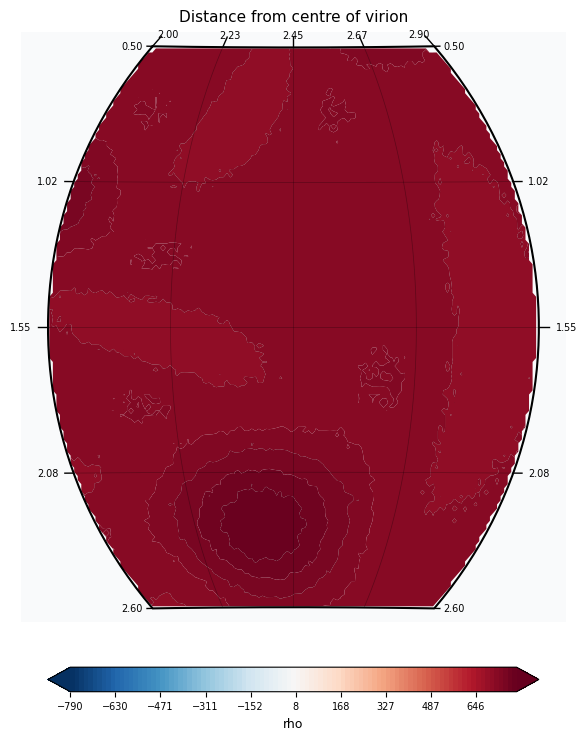

In [60]:
plot_contour_curved(outer_df,value_col='rho', title='Distance from centre of virion',
                       theta_lim=(0.5, 2.6), phi_lim=(2, 2.9), n_levels=100)

In [76]:
import numpy as np
import plotly.graph_objects as go

# ----------------------------
# 1) Parameter grid (periodic in phi)
# ----------------------------
n_th, n_ph = 180, 360
theta = np.linspace(1e-3, np.pi - 1e-3, n_th)        # avoid poles
phi   = np.linspace(0, 2*np.pi, n_ph, endpoint=False)  # periodic seam at 0/2π
TH, PH = np.meshgrid(theta, phi, indexing="ij")

dtheta = theta[1] - theta[0]
dphi   = phi[1] - phi[0]

# ----------------------------
# 2) Bulge model: radial graph r(θ,φ)
# ----------------------------
R = 1.0
a = 0.35
sigma = 0.22
theta0, phi0 = np.pi/3, np.pi/4

cos_d = (np.sin(TH)*np.sin(theta0)*np.cos(PH - phi0) + np.cos(TH)*np.cos(theta0))
d = np.arccos(np.clip(cos_d, -1.0, 1.0))

r = R * (1.0 + a*np.exp(-(d**2)/(2*sigma**2)))

# Embedding in R^3
X = r*np.sin(TH)*np.cos(PH)
Y = r*np.sin(TH)*np.sin(PH)
Z = r*np.cos(TH)

# ----------------------------
# 3) Periodic derivatives in φ to avoid seam artifacts
# ----------------------------
def dphi_periodic(A, dphi):
    # central difference with periodic wrap
    return (np.roll(A, -1, axis=1) - np.roll(A, +1, axis=1)) / (2.0 * dphi)

def dphi2_periodic(A, dphi):
    # second derivative with periodic wrap
    return (np.roll(A, -1, axis=1) - 2.0*A + np.roll(A, +1, axis=1)) / (dphi**2)

def dtheta_nonperiodic(A, dtheta):
    # high-quality finite differences in theta
    return np.gradient(A, dtheta, axis=0, edge_order=2)

# First derivatives
X_th = dtheta_nonperiodic(X, dtheta);  X_ph = dphi_periodic(X, dphi)
Y_th = dtheta_nonperiodic(Y, dtheta);  Y_ph = dphi_periodic(Y, dphi)
Z_th = dtheta_nonperiodic(Z, dtheta);  Z_ph = dphi_periodic(Z, dphi)

r_th = np.stack([X_th, Y_th, Z_th], axis=-1)
r_ph = np.stack([X_ph, Y_ph, Z_ph], axis=-1)

# First fundamental form
E = np.sum(r_th * r_th, axis=-1)
F = np.sum(r_th * r_ph, axis=-1)
G = np.sum(r_ph * r_ph, axis=-1)

# Unit normal
N = np.cross(r_th, r_ph)
Nn = np.linalg.norm(N, axis=-1)
n = N / (Nn[..., None] + 1e-12)

# Second derivatives
X_thth = dtheta_nonperiodic(X_th, dtheta)
Y_thth = dtheta_nonperiodic(Y_th, dtheta)
Z_thth = dtheta_nonperiodic(Z_th, dtheta)

X_phph = dphi2_periodic(X, dphi)
Y_phph = dphi2_periodic(Y, dphi)
Z_phph = dphi2_periodic(Z, dphi)

# Mixed: d/dθ(d/dφ)
X_thph = dtheta_nonperiodic(X_ph, dtheta)
Y_thph = dtheta_nonperiodic(Y_ph, dtheta)
Z_thph = dtheta_nonperiodic(Z_ph, dtheta)

r_thth = np.stack([X_thth, Y_thth, Z_thth], axis=-1)
r_thph = np.stack([X_thph, Y_thph, Z_thph], axis=-1)
r_phph = np.stack([X_phph, Y_phph, Z_phph], axis=-1)

# Second fundamental form
e = np.sum(r_thth * n, axis=-1)
f = np.sum(r_thph * n, axis=-1)
g = np.sum(r_phph * n, axis=-1)

# Gaussian curvature
den = (E*G - F**2)
K = (e*g - f**2) / (den + 1e-12)

# ----------------------------
# 4) Option B: close the seam by duplicating the first φ-column
#    Do this AFTER computing K so the seam matches in color too.
# ----------------------------
X = np.concatenate([X, X[:, :1]], axis=1)
Y = np.concatenate([Y, Y[:, :1]], axis=1)
Z = np.concatenate([Z, Z[:, :1]], axis=1)
K = np.concatenate([K, K[:, :1]], axis=1)

# ----------------------------
# 5) Interactive Plotly surface colored by K (no extra markers)
# ----------------------------
# Downsample for smoother interactivity (tweak step if desired)
step = 3
Xs, Ys, Zs = X[::step, ::step], Y[::step, ::step], Z[::step, ::step]
Ks = K[::step, ::step]

fig = go.Figure(
    data=[
        go.Surface(
            x=Xs, y=Ys, z=Zs,
            surfacecolor=Ks,     # color by Gaussian curvature
            showscale=True,
            opacity=0.98,
            colorbar=dict(title="K")
        )
    ]
)

fig.update_layout(
    title="Bulged sphere colored by Gaussian curvature K",
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, t=40, b=0),
)

fig.show()

# Optional: save as a shareable interactive HTML file
# fig.write_html("bulged_sphere_K_interactive.html", include_plotlyjs="cdn")



In [77]:
import numpy as np
import plotly.graph_objects as go

# ----------------------------
# 1) Parameter grid (periodic in phi)
# ----------------------------
n_th, n_ph = 180, 360
theta = np.linspace(1e-3, np.pi - 1e-3, n_th)          # avoid poles
phi   = np.linspace(0, 2*np.pi, n_ph, endpoint=False)  # periodic seam
TH, PH = np.meshgrid(theta, phi, indexing="ij")

dtheta = theta[1] - theta[0]
dphi   = phi[1] - phi[0]

# ----------------------------
# 2) DIMPLE model: radial graph r(θ,φ)
# ----------------------------
R = 1.0
depth = 0.30     # dimple depth fraction of R (keep < 1)
sigma = 0.22
theta0, phi0 = np.pi/3, np.pi/4

# angular distance to dimple center
cos_d = (np.sin(TH)*np.sin(theta0)*np.cos(PH - phi0) + np.cos(TH)*np.cos(theta0))
d = np.arccos(np.clip(cos_d, -1.0, 1.0))

# Dimple: inward indentation (note the minus sign)
r = R * (1.0 - depth*np.exp(-(d**2)/(2*sigma**2)))

# Safety (avoid any accidental negative radii if depth is too large)
r = np.maximum(r, 1e-6)

# Embedding in R^3
X = r*np.sin(TH)*np.cos(PH)
Y = r*np.sin(TH)*np.sin(PH)
Z = r*np.cos(TH)

# ----------------------------
# 3) Periodic derivatives in φ to avoid seam artifacts
# ----------------------------
def dphi_periodic(A, dphi):
    return (np.roll(A, -1, axis=1) - np.roll(A, +1, axis=1)) / (2.0 * dphi)

def dphi2_periodic(A, dphi):
    return (np.roll(A, -1, axis=1) - 2.0*A + np.roll(A, +1, axis=1)) / (dphi**2)

def dtheta_nonperiodic(A, dtheta):
    return np.gradient(A, dtheta, axis=0, edge_order=2)

# First derivatives
X_th = dtheta_nonperiodic(X, dtheta);  X_ph = dphi_periodic(X, dphi)
Y_th = dtheta_nonperiodic(Y, dtheta);  Y_ph = dphi_periodic(Y, dphi)
Z_th = dtheta_nonperiodic(Z, dtheta);  Z_ph = dphi_periodic(Z, dphi)

r_th = np.stack([X_th, Y_th, Z_th], axis=-1)
r_ph = np.stack([X_ph, Y_ph, Z_ph], axis=-1)

# First fundamental form
E = np.sum(r_th * r_th, axis=-1)
F = np.sum(r_th * r_ph, axis=-1)
G = np.sum(r_ph * r_ph, axis=-1)

# Unit normal
N = np.cross(r_th, r_ph)
Nn = np.linalg.norm(N, axis=-1)
n = N / (Nn[..., None] + 1e-12)

# Second derivatives
X_thth = dtheta_nonperiodic(X_th, dtheta)
Y_thth = dtheta_nonperiodic(Y_th, dtheta)
Z_thth = dtheta_nonperiodic(Z_th, dtheta)

X_phph = dphi2_periodic(X, dphi)
Y_phph = dphi2_periodic(Y, dphi)
Z_phph = dphi2_periodic(Z, dphi)

# Mixed derivatives: d/dθ(d/dφ)
X_thph = dtheta_nonperiodic(X_ph, dtheta)
Y_thph = dtheta_nonperiodic(Y_ph, dtheta)
Z_thph = dtheta_nonperiodic(Z_ph, dtheta)

r_thth = np.stack([X_thth, Y_thth, Z_thth], axis=-1)
r_thph = np.stack([X_thph, Y_thph, Z_thph], axis=-1)
r_phph = np.stack([X_phph, Y_phph, Z_phph], axis=-1)

# Second fundamental form
e = np.sum(r_thth * n, axis=-1)
f = np.sum(r_thph * n, axis=-1)
g = np.sum(r_phph * n, axis=-1)

# Gaussian curvature
den = (E*G - F**2)
K = (e*g - f**2) / (den + 1e-12)

# ----------------------------
# 4) Option B: close the seam by duplicating the first φ-column
# ----------------------------
X = np.concatenate([X, X[:, :1]], axis=1)
Y = np.concatenate([Y, Y[:, :1]], axis=1)
Z = np.concatenate([Z, Z[:, :1]], axis=1)
K = np.concatenate([K, K[:, :1]], axis=1)

# ----------------------------
# 5) Interactive Plotly surface colored by K
# ----------------------------
step = 3
Xs, Ys, Zs = X[::step, ::step], Y[::step, ::step], Z[::step, ::step]
Ks = K[::step, ::step]

fig = go.Figure(
    data=[
        go.Surface(
            x=Xs, y=Ys, z=Zs,
            surfacecolor=Ks,
            showscale=True,
            opacity=0.98,
            colorbar=dict(title="K"),
        )
    ]
)

fig.update_layout(
    title="Dimpled sphere colored by Gaussian curvature K",
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, t=40, b=0),
)

fig.show()

# Optional: save to HTML
# fig.write_html("dimpled_sphere_K_interactive.html", include_plotlyjs="cdn")


In [79]:
import numpy as np
import plotly.graph_objects as go

# ----------------------------
# Grid
# ----------------------------
n_th, n_ph = 180, 360
theta = np.linspace(1e-3, np.pi - 1e-3, n_th)
phi   = np.linspace(0, 2*np.pi, n_ph, endpoint=False)
TH, PH = np.meshgrid(theta, phi, indexing="ij")

dtheta = theta[1] - theta[0]
dphi   = phi[1] - phi[0]

# ----------------------------
# Periodic derivatives in phi
# ----------------------------
def dphi_periodic(A):
    return (np.roll(A, -1, axis=1) - np.roll(A, +1, axis=1)) / (2.0 * dphi)

def dphi2_periodic(A):
    return (np.roll(A, -1, axis=1) - 2.0*A + np.roll(A, +1, axis=1)) / (dphi**2)

def dtheta_nonperiodic(A):
    return np.gradient(A, dtheta, axis=0, edge_order=2)

def gaussian_curvature_from_xyz(X, Y, Z):
    X_th = dtheta_nonperiodic(X);  X_ph = dphi_periodic(X)
    Y_th = dtheta_nonperiodic(Y);  Y_ph = dphi_periodic(Y)
    Z_th = dtheta_nonperiodic(Z);  Z_ph = dphi_periodic(Z)

    r_th = np.stack([X_th, Y_th, Z_th], axis=-1)
    r_ph = np.stack([X_ph, Y_ph, Z_ph], axis=-1)

    E = np.sum(r_th*r_th, axis=-1)
    F = np.sum(r_th*r_ph, axis=-1)
    G = np.sum(r_ph*r_ph, axis=-1)

    N = np.cross(r_th, r_ph)
    Nn = np.linalg.norm(N, axis=-1)
    n = N / (Nn[..., None] + 1e-12)

    X_thth = dtheta_nonperiodic(X_th)
    Y_thth = dtheta_nonperiodic(Y_th)
    Z_thth = dtheta_nonperiodic(Z_th)

    X_phph = dphi2_periodic(X)
    Y_phph = dphi2_periodic(Y)
    Z_phph = dphi2_periodic(Z)

    X_thph = dtheta_nonperiodic(X_ph)
    Y_thph = dtheta_nonperiodic(Y_ph)
    Z_thph = dtheta_nonperiodic(Z_ph)

    r_thth = np.stack([X_thth, Y_thth, Z_thth], axis=-1)
    r_thph = np.stack([X_thph, Y_thph, Z_thph], axis=-1)
    r_phph = np.stack([X_phph, Y_phph, Z_phph], axis=-1)

    e = np.sum(r_thth*n, axis=-1)
    f = np.sum(r_thph*n, axis=-1)
    g = np.sum(r_phph*n, axis=-1)

    den = (E*G - F**2)
    K = (e*g - f**2) / (den + 1e-12)
    return K

def close_seam(A):
    return np.concatenate([A, A[:, :1]], axis=1)

# ----------------------------
# Angular distance from tug direction
# ----------------------------
def angular_distance(theta0, phi0):
    cos_d = (np.sin(TH)*np.sin(theta0)*np.cos(PH - phi0) + np.cos(TH)*np.cos(theta0))
    return np.arccos(np.clip(cos_d, -1.0, 1.0))

# ----------------------------
# Target Kmax from your bulge
# ----------------------------
R = 1.0
bulge_amp = 0.35
sigma_bulge = 0.22
theta0, phi0 = np.pi/3, np.pi/4

d = angular_distance(theta0, phi0)
r_bulge = R * (1.0 + bulge_amp*np.exp(-(d**2)/(2*sigma_bulge**2)))

Xb = r_bulge*np.sin(TH)*np.cos(PH)
Yb = r_bulge*np.sin(TH)*np.sin(PH)
Zb = r_bulge*np.cos(TH)

Kb = gaussian_curvature_from_xyz(Xb, Yb, Zb)
target_Kmax = float(np.max(Kb))
print(f"Target bulge Kmax = {target_Kmax:.6f}")

# ----------------------------
# Teardrop tug model (axisymmetric)
# s(d) = exp(-(d/sigma)^p) with p ~ 1 gives a long, quasi-conical shoulder.
# ----------------------------
sigma = 0.75   # bigger = broader shoulder (less likely to create K<0)
p = 1.15       # ~1 = long tail / teardrop feel; increase to make it more "bump-like"

def teardrop_curvature(A):
    s = np.exp(- (d / sigma)**p)
    r = R * (1.0 + A*s)
    X = r*np.sin(TH)*np.cos(PH)
    Y = r*np.sin(TH)*np.sin(PH)
    Z = r*np.cos(TH)
    K = gaussian_curvature_from_xyz(X, Y, Z)
    return float(np.min(K)), float(np.max(K)), (X, Y, Z, K)

# ----------------------------
# Find A such that:
#   (1) Kmin(A) > 0 (convex everywhere)
#   (2) Kmax(A) ~= target_Kmax
# Strategy:
#   - grow A until either Kmin hits 0 (convexity breaks) or Kmax passes target.
#   - then bisection on A for Kmax, staying within convex region.
# ----------------------------
A_lo = 0.0
Kmin_lo, Kmax_lo, _ = teardrop_curvature(A_lo)

A_hi = 0.2
for _ in range(40):
    Kmin_hi, Kmax_hi, _ = teardrop_curvature(A_hi)
    if Kmin_hi <= 0:
        # went too far; convexity broke
        break
    if Kmax_hi >= target_Kmax:
        # we bracketed the target within convex regime
        break
    A_hi *= 1.25

Kmin_hi, Kmax_hi, _ = teardrop_curvature(A_hi)

if Kmin_hi <= 0:
    raise RuntimeError(
        "With current sigma,p, convexity breaks before reaching the target Kmax. "
        "Try increasing sigma (broader shoulder) or lowering p (longer tail)."
    )
if Kmax_hi < target_Kmax:
    raise RuntimeError(
        "Even at the tested A_hi the Kmax didn't reach target. "
        "Try increasing A_hi cap or decreasing sigma a bit."
    )

# Bisection for Kmax match (convexity should hold across [A_lo,A_hi] by construction)
for _ in range(35):
    A_mid = 0.5*(A_lo + A_hi)
    Kmin_mid, Kmax_mid, _ = teardrop_curvature(A_mid)
    if Kmax_mid >= target_Kmax:
        A_hi = A_mid
    else:
        A_lo = A_mid

A_star = 0.5*(A_lo + A_hi)
Kmin_star, Kmax_star, (X, Y, Z, K) = teardrop_curvature(A_star)
print(f"Tuned teardrop: A={A_star:.6f}, sigma={sigma}, p={p}")
print(f"Kmin={Kmin_star:.6f} (should be >0), Kmax={Kmax_star:.6f} (target {target_Kmax:.6f})")

# ----------------------------
# Plot interactive surface colored by K (Option B seam close)
# ----------------------------
Xc, Yc, Zc, Kc = close_seam(X), close_seam(Y), close_seam(Z), close_seam(K)

step = 3
fig = go.Figure(go.Surface(
    x=Xc[::step, ::step],
    y=Yc[::step, ::step],
    z=Zc[::step, ::step],
    surfacecolor=Kc[::step, ::step],
    showscale=True,
    colorbar=dict(title="K"),
    opacity=0.98
))

fig.update_layout(
    title=f"Convex teardrop tug tuned to bulge Kmax≈{target_Kmax:.2f}  |  A={A_star:.3f}, sigma={sigma}, p={p}",
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        aspectmode="data",
    ),
    margin=dict(l=0, r=0, t=50, b=0),
)

fig.show()


Target bulge Kmax = 22.022509
Tuned teardrop: A=0.080592, sigma=0.75, p=1.15
Kmin=0.883874 (should be >0), Kmax=22.022509 (target 22.022509)
